# **TS1** Síntesis y operaciones de señales.
García Corona, Iara Paula </br>
Ejercicio 1:

#### Introducción:</br>
En el ejercicio se busca generar y analizar distintas señales discretas usando 1000 muestras a través de sus gráficos en el dominio del tiempo y la frecuencia. </br>Para el análisis espectral se introduce y aplica el concepto de FFT (Fast Fourier Transform) que permite destacar las frecuencias que componen una señal y la energía con la que contribuyen a ella.

Primero se realiza un seteo generalizado. Defino mi función seno y del espectro en dB para el ejericicio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)

def espectro_db(xx):
    N=len(xx)
    tr=(1/N)*np.fft.fft(xx)
    modulo_tr=np.abs(tr)
    modulo_tr_db = 10 * np.log10(2*(modulo_tr[:N//2]) ** 2)
    return modulo_tr_db


"Frecuencia de la señal"
ff=2000 # Hz ff=1/T
N= 1000 # Muestras totales
nn=np.arange(0,N) #Eje temporal discreto
"Cantidad mínima de muestras por periodo"
mpp=10

"Frecuencia de muestreo"
fs = ff*mpp
k = np.arange(0,N//2)
frec= k * fs/N


Las muestras por periodo se definen como $$\frac{f_s}{f} = M$$ En este caso como el resto de los items no piden un numero específico de muestras, planteo la frecuencia de muestreo en función el ítem 1 y lo sostengo para el resto. </br> 
Además, se realiza la FFT para cada señal y se grafica en función de la frecuencia  para analizar los índices en los cuales el espéctro aporta información relevante.

##### ***Punto 1:*** Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

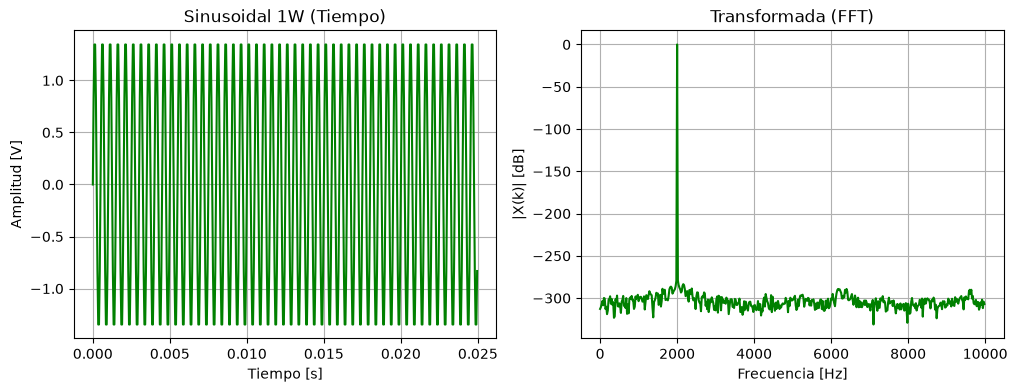

In [2]:
vmax_1=np.sqrt(2)
ph_1=0
dc_1=0 # Valor medio (alrededor del que oscila)
tt_1, xx_1= mi_funcion_sen(vmax_1, dc_1, ff, ph_1, nn, fs)

"FFT"
modulo_tr_1_db=espectro_db(xx_1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_1[:N//2], xx_1[:N//2], color="green")
ax[0].set_title("Sinusoidal 1W (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_1_db, color="green")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].grid(True)

Se grafican ambas señales en la mitad de las muestras por motivos diferentes: En el caso de la señal en el tiempo, se busca achicar la cantidad de ciclos graficados para poder ver de manera más definida la forma de la sinusoidal. Para el análisis del espectro no es necesario mostrar el total de las muestras dada la simetría Hermitiana que presentan las señales reales.
</br>En el eje horizontal se ve que el pico se encuentra en k=100.</br>
Esto tiene sentido ya que indica que la señal oscila en esa frecuencia. Siendo $f = k \cdot f_s / N$, se puede verificar que para $k=100$, $f=2000Hz$ </br>
Por simetría Hermitiana, se obtiene un segundo pico en su conjugado ($X[k]=X*[N-k]$) (Holton, 2021, p. 672, Ec. 10.25), al aplicar el módulo se obtiene otro pico positivo de igual amplitud a igual distancia de la frecuencia de Nyquist para el intervalo $[N/2;N-1]$ </br> en el eje vertical se ve la amplitud de la frecuencia, al ser los picos los únicos puntos con altura mucho mayor 0dB, se puede entender que solo esa frecuencia contribuye a la señal por ser una sinusoidal pura sin ruido. El ruido a -300dB se debe al error de redondeo usado por la computadora al calcular la FFT, no a un ruido propio de la señal.</br>
(Agrego la cita de donde se extrajo la información para poder consultarlo en el futuro en caso de ser necesario)

##### ***Punto 2:*** Misma señal con 2 W de potencia media y desfasada en π/2.

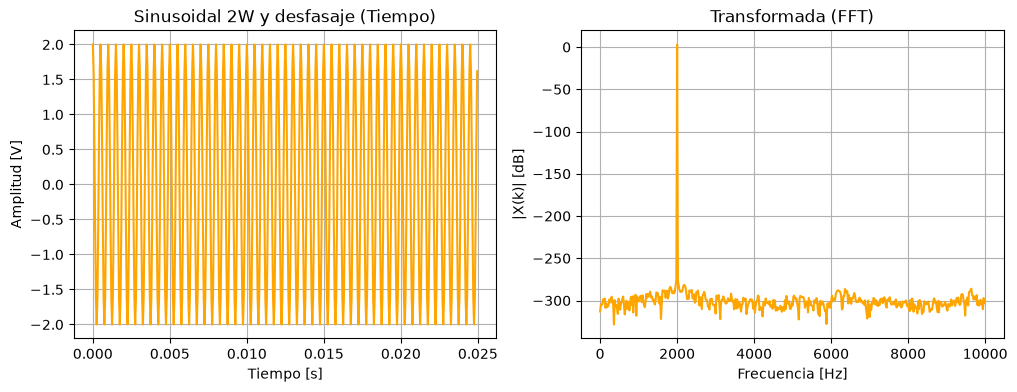

In [3]:
P_m=2 #potencia pedida
vmax_2=np.sqrt(P_m*2)
ph_2=1/4 # Es la proporción que hay que desfasar, la función tiene 2pi*ph
dc_2=0
tt_2, xx_2= mi_funcion_sen(vmax_2, dc_2, ff, ph_2, nn, fs)

"FFT"
modulo_tr_2_db=espectro_db(xx_2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_2[:N//2], xx_2[:N//2], color="orange")
ax[0].set_title("Sinusoidal 2W y desfasaje (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_2_db, color="orange")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].grid(True)

En este ítem los gráficos resultan muy similares a los analizados en el primer punto. Esto se debe a que el aumento de potencia se ve directamente reflejado en la amplitud, tanto de la señal en funcion del tiempo como en el pico de la transformada, mientras que el desfasaje es una componente que se visualiza en la fase del espectro, más no en su magnitud que es lo se grafica.
</br> Al modificar la potencia de 1W a 2W, la diferencia de altura en dB para el gráfico en función de la frecuencia resulta ser $20 \cdot log_{10}(\frac{2V}{\sqrt 2 V})\approx 3.01dB$, esta diferencia resulta muy chica en proporción a la escala del gráfico, por lo que a simple vista resulta complicado distinguirlo. Por eso se realiza a continuación un ploteo de ambos gráfico haciendo foco alrededor de los 0dB de cada gráfica.

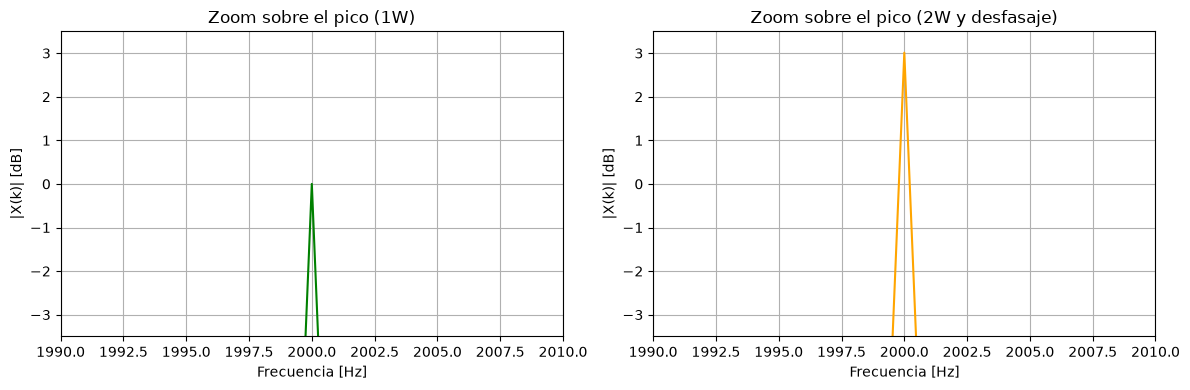

In [4]:
# --- Zoom sobre el pico: comparación 1W vs 2W ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(frec, modulo_tr_1_db, color="green")
ax[0].set_title("Zoom sobre el pico (1W)")
ax[0].set_xlabel("Frecuencia [Hz]")
ax[0].set_ylabel("|X(k)| [dB]")
ax[0].set_xlim(1990, 2010)
ax[0].set_ylim(-3.5, 3.5)
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_2_db, color="orange")
ax[1].set_title("Zoom sobre el pico (2W y desfasaje)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].set_xlim(1990, 2010)
ax[1].set_ylim(-3.5, 3.5)
ax[1].grid(True)

plt.tight_layout()
plt.show()

##### ***Punto 3:*** Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W

La potencia de una señal con valor medio igual a cero ($\mu=0$) resulta ser igual a su varianza, por lo que se define: $$\sigma^2=pot_{ruido}=0.1$$ y dado que la función pide la *desviación estandar* se aplica la raíz a la varianza ($\sigma=\sqrt {0.1}$). Luego se implementa la función que devuelve valores aleatorios enmarcados en una distribución normal. 

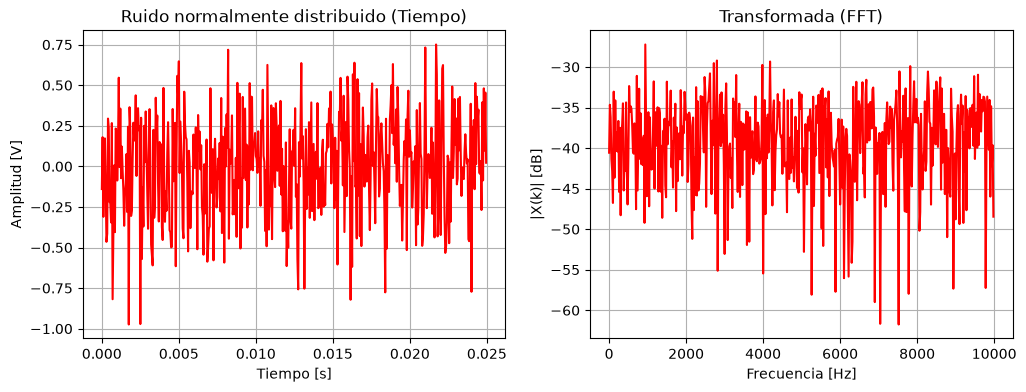

In [5]:
dc_3=0

"Definiciones para el ruido"
mu=0 #valor 
# Para señales con valor medio 0, la potencia media es igual a la varianza. P=sigma^2
sig_ruido=np.sqrt(0.1)# dispersión de los puntos respecto de la media
xx_3=np.random.normal(mu,sig_ruido,N);
tt_3=nn/fs #podría usar siempre el mismo tt pero no quiero modificar la función

"FFT"
modulo_tr_3_db=espectro_db(xx_3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_3[:N//2], xx_3[:N//2], color="red")
ax[0].set_title("Ruido normalmente distribuido (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_3_db, color="red")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].grid(True)

Al ser esta una señal de ruido generada de manera aleatoria, se puede ver en el gráfico del tiempo la ausencia de un patrón común. En la FFT no resalta una única frecuencia, sino que se visualizan picos aleatorios, reforzando el hecho de que no hay una periodicidad en la señal sin que se destaque ninguna frecuencia.

##### ***Punto 4:*** Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W.

Para el ruido uniformemente distribuido se utiliza que $\int_{a}^{-a} p_X(x) \, dx=1$, sabiendo que la distribución es un escalón, el área debjajo de la curva será el área de un rectángulo. $p_X(x)$ es la altura del rectángulo y la densidad de probabilidad es constante para el intervalo, $p_X(x)=h$, permitiendo despejar $h=\frac{1}{2a}$. </br>
La varianza se define como $\sigma^2=\int_{-a}^{a} x^2 p_X(x) \, dx=\frac{a^2}{3}$

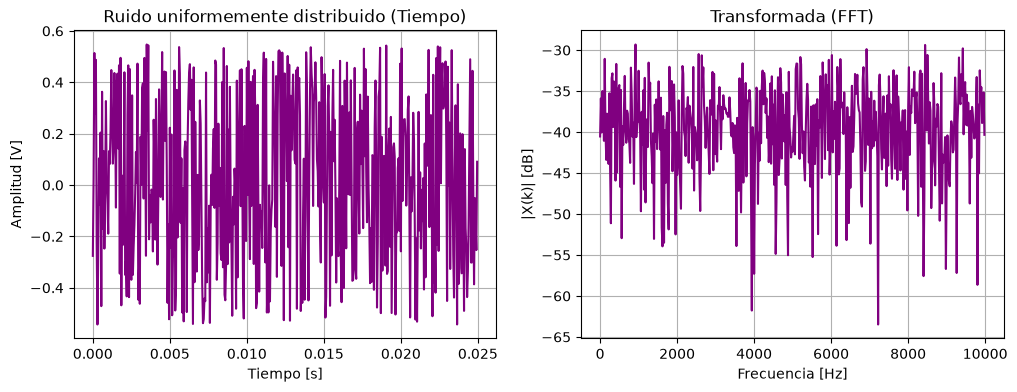

In [6]:
lim=np.sqrt(0.1*3)
xx_4=np.random.uniform(-lim,lim,N);
tt_4=nn/fs

"FFT"

modulo_tr_4_db=espectro_db(xx_4)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_4[:N//2], xx_4[:N//2], color="purple")
ax[0].set_title("Ruido uniformemente distribuido (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_4_db, color="purple")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].grid(True)

En este caso, el ruido está acotado entre los límites definidos como $a$ y $-a$ y es posible ver una distribución semejante a un rectángulo. Para el gráfico de la FFT los picos no destacan ninguna frecuencia pero sí tienen una estructura más pareja entre sí, lo cual tiene sentido al recordar el tipo de distribución de la que parte a pesar de su aleatoriedad. 

##### ***Punto 5:*** Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%

Para la onda cuadrada se utiliza la función <span style="color:blue;">signal.square</span> definida en la librería scipy.signal. Esta tiene como primer parámetro el punto del ciclo que se está evaluando ($ 2\pi f t$) y el segundo indica el ciclo de actividad, lo que define que la primera mitad de la onda sea positiva ($+V_{max}$) postiva y la mitad restante negativa ($-V_{max}$).

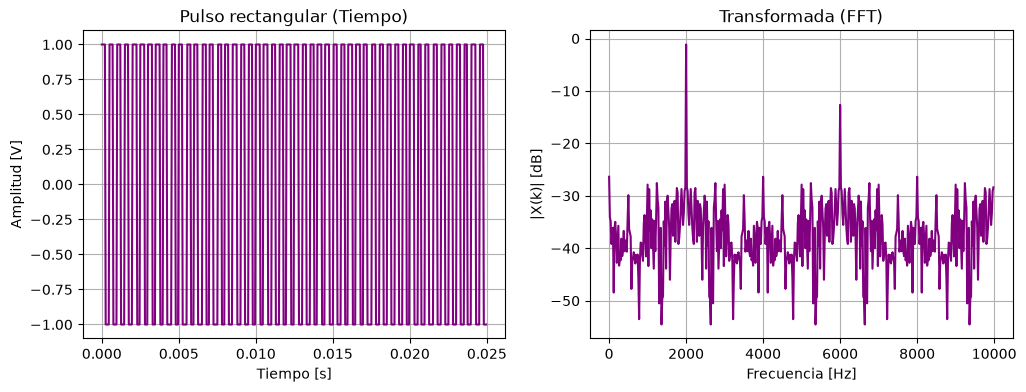

In [13]:
pot_5=1 #
vmax_5=np.sqrt(pot_5)
tt_5=nn/fs #podría usar siempre el mismo tt pero no quiero modificar la función
xx_5=vmax_5*signal.square(2*np.pi*ff*tt_5,0.5)

"FFT"

modulo_tr_5_db=espectro_db(xx_5)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_5[:N//2], xx_5[:N//2], color="purple")
ax[0].set_title("Pulso rectangular (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(frec, modulo_tr_5_db, color="purple")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("|X(k)| [dB]")
ax[1].grid(True)

En el gráfico del dominio temporal se ve lo esperado: un pulso rectangular que cambia de ($+V_{max}$) a ($-V_{max}$) a la mitad del ciclo y vuelve a subir al iniciar uno nuevo. En el dominio de la frecuencia se ve el comportamiento esperado para una onda cuadrada, la cual está compuesta por inifinitos senos que corresponden a los armónicos impares de la frecuencia fundamental. Al analizar la magnitud de la transformada de Fourier se evidencia lo significativo que es el aporte que realizan los armónicos impares de la frecuencia fundamental ($1\cdot f_0=2000Hz; 3\cdot f_0=6000Hz$).

#### Teorema de Parseval:</br>

En el dominio temporal $x[n]$ muestra cuánto vale la señal en la muestra $n$, en el dominio de la frecuencia $X[k]$ expone cuánto contribuye esa frecuencia $k$ en la señal completa.
</br>
El teorema establece que la energía total es la misma sin importar en qué dominio se calcule, porque la transformada de Fourier no cambia la información. Lo que sucede es que esta se reordena y distribuye la energía en el aporte de las distintas frecuencias que componen la señal. 
</br></br>
$P=\frac{E}{N}=\frac{1}{N}\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1} |X[k]|^2$

In [18]:
pot_sigt_1 = (1/N) * np.sum(xx_1**2)
pot_sigf_1 = (1/N**2) * np.sum(np.abs(np.fft.fft(xx_1))**2)
print(f"Señal 1W -> Potencia en tiempo: {pot_sigt_1:.4f} W | Potencia en frecuencia: {pot_sigf_1:.4f} W")
pot_sigt_2 = (1/N) * np.sum(xx_2**2)
pot_sigf_2 = (1/N**2) * np.sum(np.abs(np.fft.fft(xx_2))**2)
print(f"Señal 2W -> Potencia en tiempo: {pot_sigt_2:.4f} W | Potencia en frecuencia: {pot_sigf_2:.4f} W")

Señal 1W -> Potencia en tiempo: 1.0000 W | Potencia en frecuencia: 1.0000 W
Señal 2W -> Potencia en tiempo: 2.0000 W | Potencia en frecuencia: 2.0000 W


Es posible entonces verificar que las potencias con las que se requiere generar las señales son efectivamente las que estas tienen, en ambos dominios.

#### Conclusiones: </br>
En este trabajo se realizó el análisis de cinco señales discretas distintas, comparando el comportamiento en el dominio temporal con el de su transformada de Fourier, es decir, en su dominio frecuencial. Las señales como las sinusoides y el pulso rectangular concentran su energía en frecuencias puntuales, mientras que las señales aleatorias distribuyen su energía a lo largo de todo su espectro sin enfocar en una puntual. También se pudo observar que la señal sinusoidal pura tiene toda su energía concentrada en un punto de su espectro, mientras que el pulso rectangular revela mayor aporte por parte de los armónicos impares. </br>
Por otro lado, a través del teorema de Parseval se pudo comprobar que la potencia con la que se pide generar la señal es efectivamente la que tiene en ambos dominios, permitiendo reforzar el concepto de equivalencia entre ambas representaciones de una misma señal.
Este ejercicio permitió ver la relación entre el dominio temporal y frecuencial y explicitar la información que se puede extraer de cada uno.